In [2]:
pip install pandas numpy seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable


Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
seed = 42
np.random.seed(seed)

In [5]:
# loaded data from sns
tips_df = sns.load_dataset("tips")
tips_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [6]:
# null or missing values
tips_df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

<Axes: xlabel='tip', ylabel='Count'>

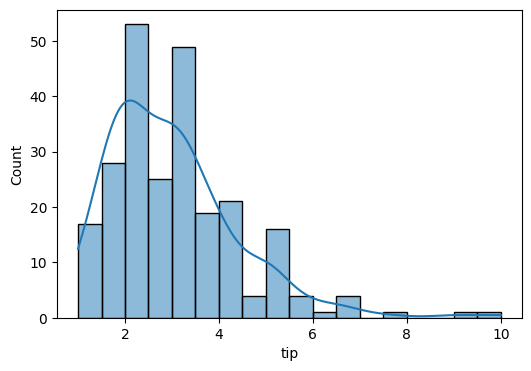

In [7]:
# Distribution of tip amounts
plt.figure(figsize=(6,4))
sns.histplot(tips_df['tip'], kde=True)

<Axes: xlabel='total_bill', ylabel='tip'>

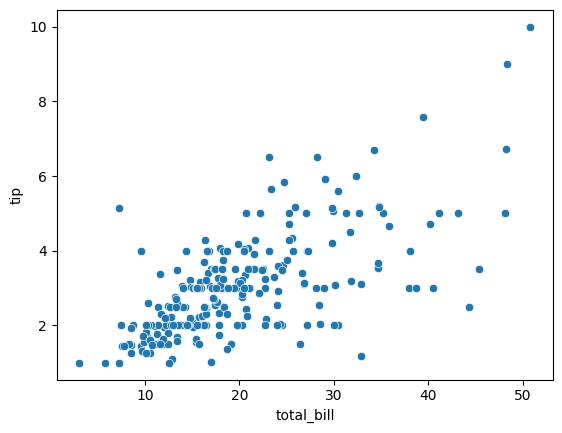

In [8]:
# Relationship between total and tip
sns.scatterplot(x="total_bill", y="tip", data=tips_df)

<Axes: xlabel='smoker', ylabel='tip'>

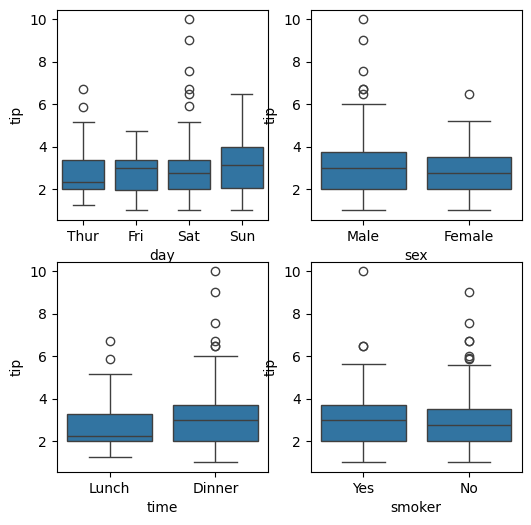

In [9]:
# Box plots for categorical variables 
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.boxplot(x="day", y="tip", data=tips_df, ax=axes[0, 0])
sns.boxplot(x="time", y="tip", data=tips_df, ax=axes[1, 0])
sns.boxplot(x="sex", y="tip", data=tips_df, ax=axes[0, 1])
sns.boxplot(x="smoker", y="tip", data=tips_df, ax=axes[1, 1])

In [10]:
# Feature Encoding
# Categorical encoding for 'sex', 'smoker, and 'time'
tips_df['sex'] = tips_df['sex'].cat.codes
tips_df['smoker'] = tips_df['smoker'].cat.codes
tips_df['time'] = tips_df['time'].cat.codes

# One-hot encoding for 'day'
tips_df = pd.get_dummies(tips_df, columns=['day'])
tips_df


,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun
0,16.99,1.01,1,1,1,2,False,False,False,True
1,10.34,1.66,0,1,1,3,False,False,False,True
2,21.01,3.50,0,1,1,3,False,False,False,True
3,23.68,3.31,0,1,1,2,False,False,False,True
4,24.59,3.61,1,1,1,4,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False
240,27.18,2.00,1,0,1,2,False,False,True,False
241,22.67,2.00,0,0,1,2,False,False,True,False
242,17.82,1.75,0,1,1,2,False,False,True,False


In [11]:
## Feature Scaling
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# numerical_features = ['total_bill', 'size']
# tips_df[numerical_features] = scaler.fit_transform(tips_df[numerical_features])
# tips_df

In [12]:
# Preparing for Modeling
X = tips_df.drop(columns='tip')
y = tips_df['tip']

print("Features:", X.columns)
print("Target:", y.name)


Features: Index(['total_bill', 'sex', 'smoker', 'time', 'size', 'day_Thur', 'day_Fri',
       'day_Sat', 'day_Sun'],
      dtype='object')
Target: tip


In [13]:
# Feature Selection and Engineering
# Calculate correlations
corr_matrix = tips_df.corr() ['tip'].sort_values(ascending=False)
corr_matrix


tip           1.000000
total_bill    0.675734
size          0.489299
day_Sun       0.125114
time          0.121629
day_Sat      -0.002790
smoker       -0.005929
day_Fri      -0.055463
sex          -0.088862
day_Thur     -0.095879
Name: tip, dtype: float64

<Axes: >

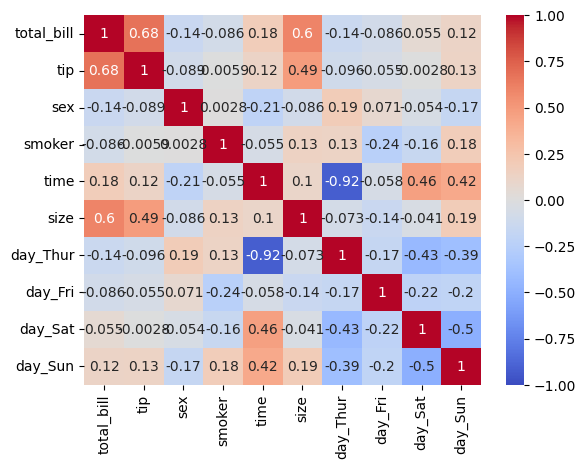

In [14]:
# Plot correlation heatmap (this method is not good for alot features!)
sns.heatmap(tips_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)

In [15]:
# Selecting Initial Features
selected_features = ['total_bill', 'size', 'day_Sun', 'day_Sat', 'time']
X_selected = tips_df[selected_features]

print("Selected features:", X_selected.columns)

Selected features: Index(['total_bill', 'size', 'day_Sun', 'day_Sat', 'time'], dtype='object')


In [16]:
# Engineering Features
# tip percentage(for example)
tips_df['tip_percentage'] = tips_df['tip'] / tips_df['total_bill'] * 100
tips_df



,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765
...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426


In [17]:
# Engineering Features
# per person total(for example)
tips_df['per_person_total'] = tips_df['total_bill'] / tips_df['size']
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673,8.495000
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159,3.446667
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734,7.003333
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041,11.840000
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765,6.147500
...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697,9.676667
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352,13.590000
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232,11.335000
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426,8.910000


In [18]:
# Engineering Features
# Is Weekend(for example)
tips_df['is_weekend'] = tips_df['day_Sat'] | tips_df['day_Sun']
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673,8.495000,True
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159,3.446667,True
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734,7.003333,True
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041,11.840000,True
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765,6.147500,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697,9.676667,True
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352,13.590000,True
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232,11.335000,True
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426,8.910000,True


In [19]:
# Engineering Features
# party size category(for example)
tips_df['party_size_category'] = pd.cut(tips_df['size'], bins=[0, 3, 6, np.inf], labels=['Small', 'Medium', 'Large'])
tips_df = pd.get_dummies(tips_df, columns=['party_size_category'], prefix='party')
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend,party_Small,party_Medium,party_Large
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673,8.495000,True,True,False,False
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159,3.446667,True,True,False,False
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734,7.003333,True,True,False,False
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041,11.840000,True,True,False,False
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765,6.147500,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697,9.676667,True,True,False,False
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352,13.590000,True,True,False,False
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232,11.335000,True,True,False,False
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426,8.910000,True,True,False,False


In [20]:
np.abs(tips_df.corr()['tip'].sort_values(ascending=False))

tip                 1.000000
total_bill          0.675734
size                0.489299
party_Medium        0.425938
per_person_total    0.347393
tip_percentage      0.342370
day_Sun             0.125114
time                0.121629
is_weekend          0.120198
day_Sat             0.002790
smoker              0.005929
day_Fri             0.055463
sex                 0.088862
day_Thur            0.095879
party_Small         0.425938
party_Large              NaN
Name: tip, dtype: float64

In [21]:
# Updating selecting features
selected_features = [
    'total_bill', 
    'size', 'time', 
    'day_Sat', 
    'day_Sun', 
    'tip_percentage', 
    'per_person_total', 
    'is_weekend'
    ] 
X_selected = tips_df[selected_features]
X_selected


,total_bill,size,time,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend
0,16.99,2,1,False,True,5.944673,8.495000,True
1,10.34,3,1,False,True,16.054159,3.446667,True
2,21.01,3,1,False,True,16.658734,7.003333,True
3,23.68,2,1,False,True,13.978041,11.840000,True
4,24.59,4,1,False,True,14.680765,6.147500,True
...,...,...,...,...,...,...,...,...
239,29.03,3,1,True,False,20.392697,9.676667,True
240,27.18,2,1,True,False,7.358352,13.590000,True
241,22.67,2,1,True,False,8.822232,11.335000,True
242,17.82,2,1,True,False,9.820426,8.910000,True


In [22]:
# Preparing Final Dataset for Modeling
# Split train test data
from sklearn.model_selection import train_test_split

X = X_selected.astype(np.float64)
y = tips_df['tip'].astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (195, 8)
Testing set shape: (49, 8)


In [23]:
# use assert function to be sure the sum of your train and test data is equal the total data
assert X_train.shape[0] + X_test.shape[0] == tips_df.shape[0], "Training and testing sets do not match the original dataset size"
assert X_train.shape[1] == X_test.shape[1], "Training and testing sets do not have the same number of features"

In [24]:
# Implementing Multiple Linear Regression
from sklearn.linear_model import LinearRegression

# Initialize the model
lr_model = LinearRegression()

# Fit the model
lr_model.fit(X_train, y_train)


LinearRegression()

In [25]:
# Examinign the Model
print("Intercept:", lr_model.intercept_)
print("\nCoefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"{feature}: {coef}")

Intercept: -2.320866886962074

Coefficients:
total_bill: 0.13002577242379026
size: 0.16508682357067406
time: -0.06930262929836821
day_Sat: 0.03667965407429484
day_Sun: -0.07302119768002387
tip_percentage: 0.14665460445694023
per_person_total: 0.008980631996781563
is_weekend: -0.036341543605729526


In [26]:
# Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Training set performance
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    # Test set performance
    y_test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    print("Training Set Results:")
    print(f"Mean Squared Error: {mse_train}")
    print(f"R-squared: {r2_train}")
    print(f"Root Mean Squared Error: {rmse_train}")
    print("\nTest Set Results:")
    print(f"Mean Squared Error: {mse_test}")
    print(f"R-squared: {r2_test}")
    print(f"Root Mean Squared Error: {rmse_test}")
    return mse_train, rmse_train, r2_train, mse_test, rmse_test, r2_test

# Evaluate the model
mse_train, rmse_train, r2_train, mse_test, rmse_test, r2_test = evaluate_model(lr_model, X_train, y_train, X_test, y_test)

Training Set Results:
Mean Squared Error: 0.352879689435884
R-squared: 0.8263137292297592
Root Mean Squared Error: 0.5940367744810787

Test Set Results:
Mean Squared Error: 0.21510912983832095
R-squared: 0.8279087511471122
Root Mean Squared Error: 0.4637985875768931


Text(0.5, 1.0, 'Actual vs Predicted Tips (Test Set)')

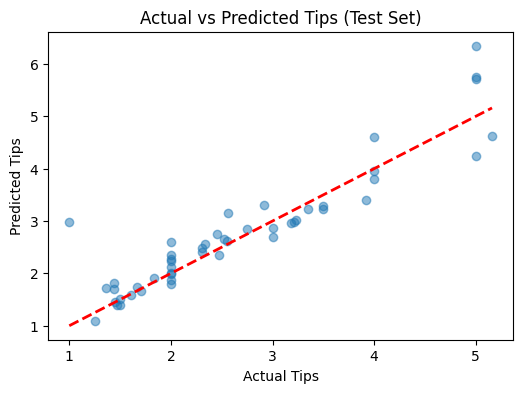

In [27]:
# Visualizing Predictions
import matplotlib.pyplot as plt

y_test_pred = lr_model.predict(X_test)

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")
plt.title("Actual vs Predicted Tips (Test Set)")


Text(0.5, 1.0, 'Residual Plot (Test Set)')

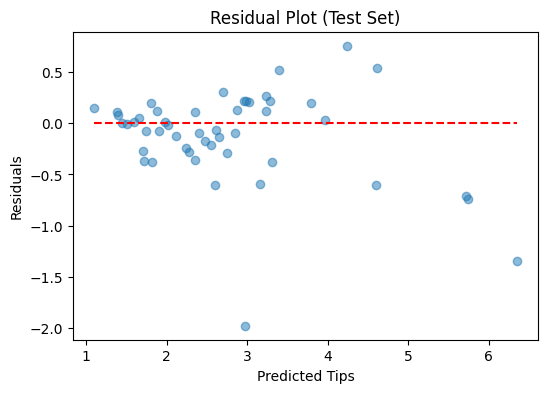

In [28]:
# Residual Analysis
residuals = y_test - y_test_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.hlines(y=0, xmin=y_test_pred.min(), xmax=y_test_pred.max(), colors='r', linestyles='--')
plt.xlabel("Predicted Tips")
plt.ylabel("Residuals")
plt.title("Residual Plot (Test Set)")

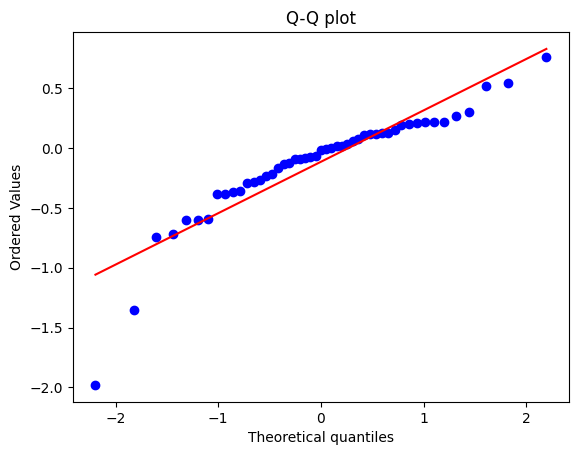

In [30]:
# Q-Q Plot
import scipy.stats as stats

fig, ax = plt.subplots()
stats.probplot(y_test - y_test_pred, plot=ax, fit=True, dist='norm')
ax.set_title("Q-Q plot")
plt.show()

Interpreting the Results
Now that we've built and evaluated our multiple linear regression model, let's interpret our results:

Model Performance: Compare the R-squared values for the training and test sets. How much of the variance in tips can our model explain? Is there a significant difference between training and test performance?

Overfitting Check: Look at the difference between training and test RMSE. A large difference might indicate overfitting.

Feature Importance: Examine the coefficients. Which features seem to have the largest impact on tip amounts?

Prediction Accuracy: Consider the RMSE on the test set. On average, how far off are our predictions in dollar terms?

Residual Analysis: Are there any patterns in the residual plot that might suggest our model is missing something?

💡 Pro Tip: Remember that while our model can show relationships between features and tips, it doesn't necessarily imply causation. Other factors not included in our dataset might also influence tipping behavior.

By implementing multiple linear regression and carefully evaluating its performance on both training and test sets, we've created a more comprehensive model for predicting tips. In the next sections, we'll explore how we can potentially improve our predictions using more advanced techniques like polynomial regression and regularization.

In [31]:
# Regularization Techniques
# Regularization helps to prevent overfitting by adding a penalty for large coefficients.
# Implementing Ridge Regression

from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

In [32]:
# Initialize Ridge model
ridge_model = Ridge(alpha=1.0)  # alpha is the regularization strength

In [33]:
# Fit the model
ridge_model.fit(X_train, y_train)

Ridge()

In [34]:
# Evaluate the model
print("Ridge Regression Results:")
evaluate_model(ridge_model, X_train, y_train, X_test, y_test)

Ridge Regression Results:
Training Set Results:
Mean Squared Error: 0.35288770220966564
R-squared: 0.8263097853677622
Root Mean Squared Error: 0.5940435187843275

Test Set Results:
Mean Squared Error: 0.2159446262589052
R-squared: 0.8272403386881034
Root Mean Squared Error: 0.46469842506609077


(0.35288770220966564,
 0.5940435187843275,
 0.8263097853677622,
 0.2159446262589052,
 0.46469842506609077,
 0.8272403386881034)

In [35]:
# Print coefficients
print("\nRidge Coefficients:")
for feature, coef in zip(X.columns, ridge_model.coef_):
    print(f"{feature}: {coef}")


Ridge Coefficients:
total_bill: 0.13112178991124576
size: 0.1563531111984617
time: -0.06574162539521487
day_Sat: 0.034610259682983674
day_Sun: -0.07226796846598078
tip_percentage: 0.14656717612676787
per_person_total: 0.006198104882632554
is_weekend: -0.037657708782971984


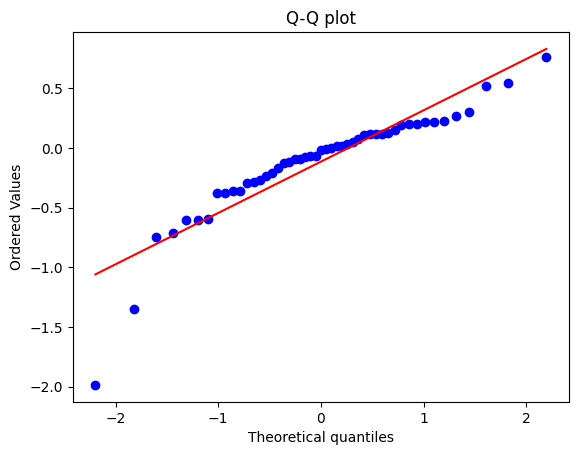

In [37]:
import scipy.stats as stats

y_test_pred = ridge_model.predict(X_test)
fig, ax = plt.subplots()
stats.probplot(y_test - y_test_pred, plot=ax, fit=True, dist='norm')
ax.set_title("Q-Q plot")
plt.show()

In [ ]:
# Implementing Lasso Regression
from sklearn.linear_model import Lasso

# Initialize Lasso model
lasso_model = Lasso(alpha=0.01)  # alpha is the regularization strength

# Fit the model
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.01)

In [39]:
# Evaluate the model
print("\nLasso Regression Results:")
evaluate_model(lasso_model, X_train, y_train, X_test, y_test)


Lasso Regression Results:
Training Set Results:
Mean Squared Error: 0.35409576451904134
R-squared: 0.8257151809072194
Root Mean Squared Error: 0.5950594630110855

Test Set Results:
Mean Squared Error: 0.2163580884625854
R-squared: 0.8269095613424916
Root Mean Squared Error: 0.465143083859779


(0.35409576451904134,
 0.5950594630110855,
 0.8257151809072194,
 0.2163580884625854,
 0.465143083859779,
 0.8269095613424916)

In [40]:
# Print non-zero coefficients
print("\nLasso Coefficients (non-zero):")
for feature, coef in zip(X.columns, lasso_model.coef_):
    if coef != 0:
        print(f"{feature}: {coef}")


Lasso Coefficients (non-zero):
total_bill: 0.13732902192563845
size: 0.09619402638758116
time: -0.03473518005282518
day_Sun: -0.0659550639082481
tip_percentage: 0.14569690878132913
per_person_total: -0.00980386733304947


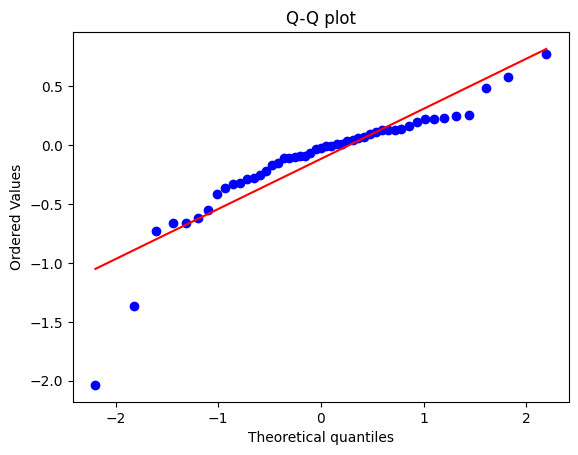

In [42]:
import scipy.stats as stats

y_test_pred = lasso_model.predict(X_test)
fig, ax = plt.subplots()
stats.probplot(y_test - y_test_pred, plot=ax, fit=True, dist='norm')
ax.set_title("Q-Q plot")
plt.show()

In [44]:
# Comparing All Models
import pandas as pd
import matplotlib.pyplot as plt

models = {
    "Multiple Linear Regression": lr_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model
}

results = []

for name, model in models.items():
    mse_train, rmse_train, r2_train, mse_test, rmse_test, r2_test = evaluate_model(model, X_train, y_train, X_test, y_test)
    results.append({
        "Model": name,
        "Train MSE": mse_train,
        "Train R2": r2_train,
        "Test MSE": mse_test,
        "Test R2": r2_test,
        "Train RMSE": np.sqrt(mse_train),
        "Test RMSE": np.sqrt(mse_test)
    })

results_df = pd.DataFrame(results)
print(results_df)

Training Set Results:
Mean Squared Error: 0.352879689435884
R-squared: 0.8263137292297592
Root Mean Squared Error: 0.5940367744810787

Test Set Results:
Mean Squared Error: 0.21510912983832095
R-squared: 0.8279087511471122
Root Mean Squared Error: 0.4637985875768931
Training Set Results:
Mean Squared Error: 0.35288770220966564
R-squared: 0.8263097853677622
Root Mean Squared Error: 0.5940435187843275

Test Set Results:
Mean Squared Error: 0.2159446262589052
R-squared: 0.8272403386881034
Root Mean Squared Error: 0.46469842506609077
Training Set Results:
Mean Squared Error: 0.35409576451904134
R-squared: 0.8257151809072194
Root Mean Squared Error: 0.5950594630110855

Test Set Results:
Mean Squared Error: 0.2163580884625854
R-squared: 0.8269095613424916
Root Mean Squared Error: 0.465143083859779
                        Model  Train MSE  Train R2  Test MSE   Test R2  \
0  Multiple Linear Regression   0.352880  0.826314  0.215109  0.827909   
1            Ridge Regression   0.352888  0.82631

([0, 1, 2],
 [Text(0, 0, 'Multiple Linear Regression'),
  Text(1, 0, 'Ridge Regression'),
  Text(2, 0, 'Lasso Regression')])

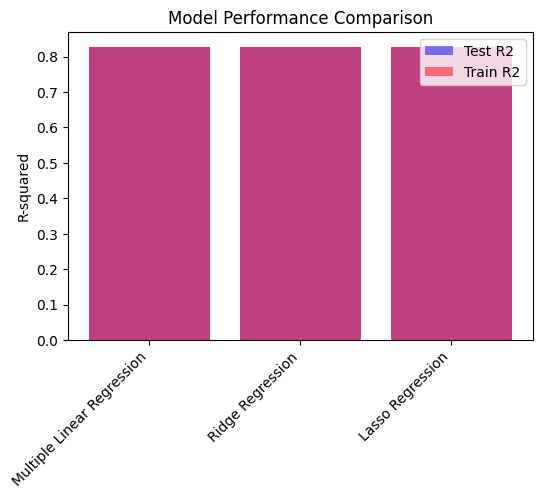

In [45]:
# Visualizing Model Comparison
plt.figure(figsize=(6, 4))
plt.bar(results_df['Model'], results_df['Test R2'], alpha=0.5, label='Test R2', color='blue')
plt.bar(results_df['Model'], results_df['Train R2'], alpha=0.5, label='Train R2', color='red')
plt.ylabel('R-squared')
plt.title('Model Performance Comparison')
plt.legend()
plt.xticks(rotation=45, ha='right')

in lasso regression model we had better results,because many features remove from total features that we had.